# 01 · Fundamentals — Graphs & Message Passing

> **Run me top to bottom.** Each cell builds on the last.
> 🎬 **Watch first:** [Message Passing — how every GNN works](https://youtu.be/eZ8AdilDccQ) ·
> bonus: [Over-smoothing — why deep GNNs fail](https://youtu.be/Xd7QVCdCr5I)

## What is a graph, in code?
A graph is **nodes** connected by **edges**. For learning we attach:
- a feature vector to each node → matrix $X \in \mathbb{R}^{N \times F}$ (`x`)
- a target $y$ (per node, or one per graph)

Connectivity is stored **sparsely** as an *edge list* `edge_index` of shape $[2, E]$ — not a dense $N\times N$
adjacency matrix. Row 0 = source nodes, row 1 = target nodes. Undirected edges are stored **both ways**.

**Source for the framework:** Gilmer et al., *Neural Message Passing for Quantum Chemistry*, ICML 2017
([arXiv:1704.01212](https://arxiv.org/abs/1704.01212)).

In [1]:
import sys, os
ROOT = os.getcwd()
if os.path.basename(ROOT) == "notebooks":
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # safe Apple-GPU fallback

import torch
from utils.device import get_device, device_report
device = get_device()
print(device_report())


Selected device : MPS
CUDA GPU        : not available
Apple MPS (Metal): available
CPU threads     : 4


## Build a tiny graph by hand and inspect the `Data` object

In [2]:
from torch_geometric.data import Data

# 5 people, 3 features each: [age(norm), is_student, hours_online]
x = torch.tensor([[0.2,1,0.8],[0.5,0,0.3],[0.3,1,0.6],[0.8,0,0.1],[0.4,0,0.5]], dtype=torch.float)
edges = [(0,1),(0,2),(1,2),(2,3),(3,4)]
undirected = edges + [(b,a) for a,b in edges]          # store both directions
edge_index = torch.tensor(undirected, dtype=torch.long).t().contiguous()
y = torch.tensor([0,0,0,1,1])                            # community label

data = Data(x=x, edge_index=edge_index, y=y)
print(data)
print("nodes:", data.num_nodes, "| edges:", data.num_edges, "| features:", data.num_node_features)
print("undirected:", data.is_undirected())

Data(x=[5, 3], edge_index=[2, 10], y=[5])
nodes: 5 | edges: 10 | features: 3
undirected: True


## Draw it

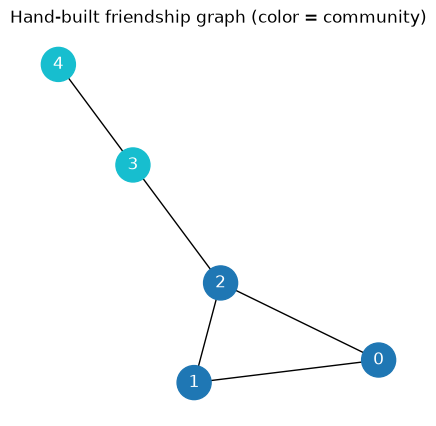

In [3]:
import networkx as nx, matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(5,5))
nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), node_color=y.tolist(),
                 cmap="tab10", node_size=600, font_color="white")
plt.title("Hand-built friendship graph (color = community)"); plt.axis("off"); plt.show()

## The core idea: Message Passing
One GNN layer updates each node $v$ from its neighbours $N(v)$:

$$ h_v' = \text{UPDATE}\Big(h_v,\ \underbrace{\textstyle\bigoplus_{u \in N(v)} \text{MESSAGE}(h_u)}_{\text{permutation-invariant aggregation}}\Big) $$

The aggregation $\bigoplus$ (sum / mean / max) must **not depend on neighbour order** — that's what makes a GNN
respect the graph's symmetry. Stacking $k$ layers lets information travel $k$ hops.

Below we implement **one GCN layer from scratch** and check it against PyG's official `GCNConv`. The GCN rule is:

$$ h_v' = W \!\!\sum_{u \in N(v)\cup\{v\}} \frac{1}{\sqrt{d_u\, d_v}}\, h_u $$

**Source:** Kipf & Welling, ICLR 2017 ([arXiv:1609.02907](https://arxiv.org/abs/1609.02907)).

In [4]:
from torch.nn import Linear
from torch_geometric.nn import MessagePassing, GCNConv
from torch_geometric.utils import add_self_loops, degree

class MyGCNConv(MessagePassing):
    def __init__(self, in_c, out_c):
        super().__init__(aggr="add")            # AGGREGATE = sum
        self.lin = Linear(in_c, out_c, bias=False)
    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        x = self.lin(x)                          # MESSAGE prep: h = xW
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        dis = deg.pow(-0.5); dis[dis == float("inf")] = 0
        norm = dis[row] * dis[col]               # 1/sqrt(d_u d_v)
        return self.propagate(edge_index, x=x, norm=norm)
    def message(self, x_j, norm):
        return norm.view(-1,1) * x_j             # scaled neighbour features

mine = MyGCNConv(3, 2); official = GCNConv(3, 2, bias=False)
with torch.no_grad(): mine.lin.weight.copy_(official.lin.weight)
out_mine, out_off = mine(x, edge_index), official(x, edge_index)
print("max abs diff:", (out_mine - out_off).abs().max().item())
print("MATCH" if torch.allclose(out_mine, out_off, atol=1e-5) else "mismatch")

max abs diff: 0.0
MATCH


## ✅ Takeaways
- Graphs = `x` + `edge_index` (+ optional `y`), stored sparsely.
- One GNN layer = **Message → Aggregate → Update**; aggregation is permutation-invariant.
- Depth = number of hops; too deep → *over-smoothing* (embeddings collapse).

**Exercises:** (1) add a self-loop check; (2) swap `aggr="add"`→`"mean"` and compare; (3) make the graph directed
and watch `is_undirected()` change.

➡ Next: **02 · Node Classification**.